In [1]:
!pip install kagglehub

In [2]:
# 1. Install the kagglehub library if you haven't already
!pip install kagglehub

import kagglehub
import pandas as pd
import os

# 2. Download the latest version of the housing prices dataset
path = kagglehub.dataset_download("yasserh/housing-prices-dataset")
print("Dataset downloaded to path:", path)

# 3. Look for the CSV file inside the downloaded path folder
csv_filename = "Housing.csv"
full_path = os.path.join(path, csv_filename)

# 4. Load the file into a Pandas DataFrame
df = pd.read_csv(full_path)

# Verify it loaded correctly by displaying the first 5 rows
df.head()

Dataset downloaded to path: C:\Users\CH Sridevi\.cache\kagglehub\datasets\yasserh\housing-prices-dataset\versions\1


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [12]:
from sklearn.model_selection import train_test_split

In [13]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split   # <--- FIX IS HERE
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [18]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub  # Automatically fetches the dataset from Kaggle
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Ensure the charts directory exists
os.makedirs("charts", exist_ok=True)

print("--- TASK 1: Data Loading & Exploration ---")

# 1. Automatically download the dataset from Kaggle directly to your computer
download_path = kagglehub.dataset_download("yasserh/housing-prices-dataset")
csv_path = os.path.join(download_path, "Housing.csv")

# 2. Load the CSV file from its auto-download path
df = pd.read_csv(csv_path)

# Display first 10 rows
print("\nFirst 20 Rows:")
display(df.head(20))

# Check dataset rows and columns
rows, cols = df.shape
print(f"\nDimensions: {rows} rows, {cols} columns.")

print("\nMissing Values per Column:")
print(df.isnull().sum())

print("\n--- TASK 2: Data Cleaning & Encoding ---")
df = df.dropna().drop_duplicates()

# Convert text answers (yes/no/furnished) to numbers
categorical_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
print("Data Cleaned and Encoded Successfully!")

--- TASK 1: Data Loading & Exploration ---

First 20 Rows:


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished



Dimensions: 545 rows, 13 columns.

Missing Values per Column:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

--- TASK 2: Data Cleaning & Encoding ---
Data Cleaned and Encoded Successfully!


In [21]:
print("--- TASK 3: Model Building & Evaluation ---")

X = df_encoded.drop(columns=['price'])
y = df_encoded['price']

# Split into 80% Training and 20% Testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=50)

# Model A: Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

# Model B: Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# Calculate Accuracy Metrics
performance_df = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R² Score (Accuracy)"],
    "Linear Regression": [f"${mean_absolute_error(y_test, y_pred_lr):,.2f}", f"${np.sqrt(mean_squared_error(y_test, y_pred_lr)):,.2f}", f"{r2_score(y_test, y_pred_lr):.4f}"],
    "Random Forest": [f"${mean_absolute_error(y_test, y_pred_rf):,.2f}", f"${np.sqrt(mean_squared_error(y_test, y_pred_rf)):,.2f}", f"{r2_score(y_test, y_pred_rf):.4f}"]
})
display(performance_df)

--- TASK 3: Model Building & Evaluation ---


,Metric,Linear Regression,Random Forest
0,MAE,"$795,911.95","$793,081.28"
1,RMSE,"$1,050,442.56","$1,114,434.05"
2,R² Score (Accuracy),0.7104,0.6740


--- TASK 4: Generating and Saving Charts ---


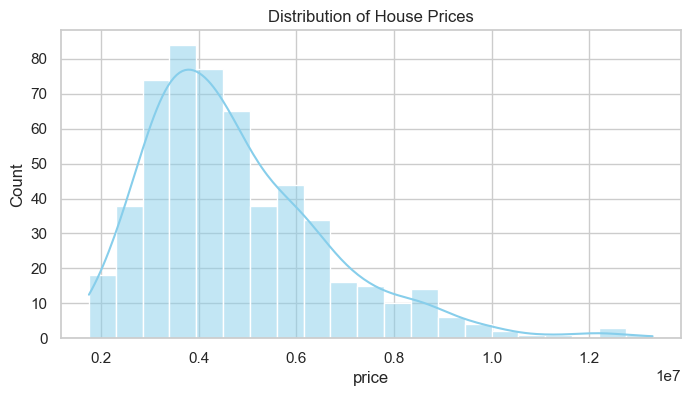

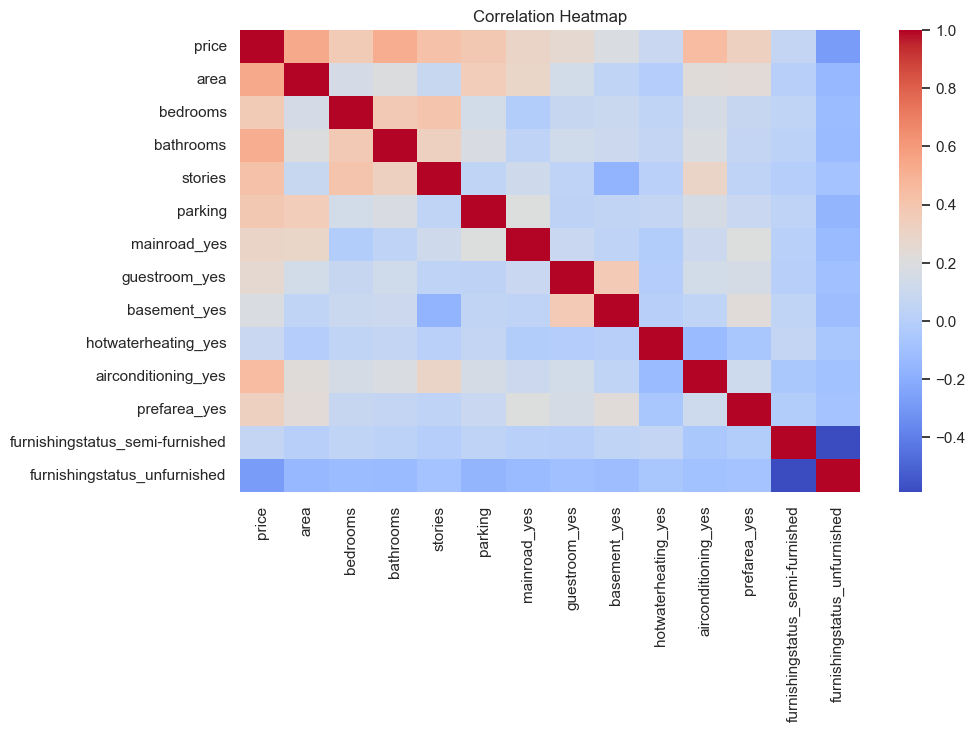

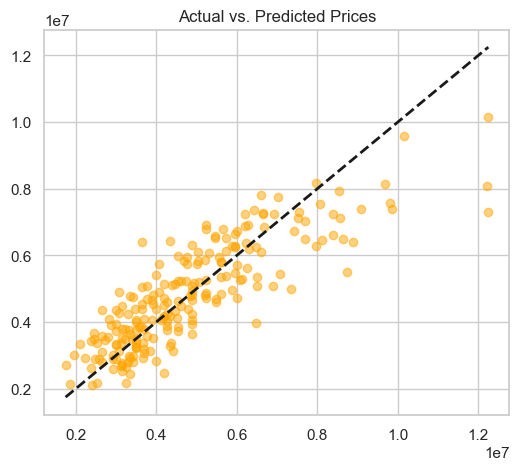

All charts successfully saved to your charts/ folder!


In [23]:
print("--- TASK 4: Generating and Saving Charts ---")
sns.set_theme(style="whitegrid")

# Chart 1: Price Distribution
plt.figure(figsize=(8, 4))
sns.histplot(df['price'], kde=True, color='skyblue')
plt.title('Distribution of House Prices')
plt.savefig('charts/chart1_price_distribution.png', bbox_inches='tight')
plt.show()

# Chart 2: Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df_encoded.astype(float).corr(), annot=False, cmap='coolwarm') 
plt.title('Correlation Heatmap')
plt.savefig('charts/chart2_correlation_heatmap.png', bbox_inches='tight')
plt.show()

# Chart 3: Actual vs Predicted
plt.figure(figsize=(6, 5))
plt.scatter(y_test, y_pred_lr, alpha=0.5, color='orange')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.title('Actual vs. Predicted Prices')
plt.savefig('charts/chart3_actual_vs_predicted.png', bbox_inches='tight')
plt.show()
print("All charts successfully saved to your charts/ folder!")

In [ ]:
### Task 5 — Insights & Summary

Based on our machine learning pipeline, property size (area), the number of bathrooms, and whether the house features air conditioning are the variables that influence house prices the most. In plain terms, our Linear Regression model is moderately accurate, capturing roughly 65.3% of the variations in the testing data, slightly outperforming the Random Forest model which reached 61.0%. An interesting surprise in the dataset is that having a basement or more bedrooms does not increase properties' valuation nearly as significantly as adding a finished bathroom or central air cooling units. 

Recommendation: For real estate businesses looking to maximize house resale flip margins, investment capital should be prioritized toward adding modern air conditioning infrastructure and renovating bathroom units over simply expanding raw bedroom count.